# Uds_xPass — Poster Extension: All La Liga Seasons + Pass-Type Calibration

This notebook extends `laliga_360_xpass.ipynb` (which only covers La Liga 2020/21, the one season with StatsBomb 360 freeze-frame data) in two ways for the final poster:

1. **Hypothesis test across all seasons** — *"passes hit with a player's weak foot are completed less often than passes hit with their strong foot"* — tested on every La Liga season available in StatsBomb's open data (not just 2020/21), using the event-only feature set (no 360 data needed/available outside 2020/21). Per season we report the raw completion-rate gap, a chi-square test, and — more importantly — a **logistic-regression coefficient on `weak_foot` controlling for pass difficulty** (length, pressure, cross/switch/through-ball/cut-back, zone, angle), since weak-foot passes are also more likely to be attempted in easier situations. Results are pooled into a forest plot + summary CSV.

2. **Calibration by pass type, across all seasons** — for each season we train an event-only xPass model (same feature recipe as the notebook's `build_features(use_360=False)`), get held-out predictions, then break out calibration (predicted vs. actual completion rate, Brier score, Expected Calibration Error) by pass type: Ordinary / Cross / Switch / Through ball / Cut-back, pooled across all seasons.

An **optional bonus section** reruns the notebook's original event-only vs. 360-enriched comparison for La Liga 2020/21 specifically (the only season with 360 data), as a sanity check on whether richer context changes the weak-foot story.

```
pip install statsbombpy xgboost scikit-learn scipy statsmodels pandas numpy matplotlib seaborn
```

**Runtime note:** StatsBomb's open data has ~20 La Liga seasons on record (mostly Messi-era Barcelona matches, ~30-40 matches per season, plus the full 2020/21 season at ~35 matches). Pulling + featurizing everything can take a while — every season's raw passes are cached to `./data/passes_<season_id>.parquet` the first time they're pulled, so re-running a cell after tweaking a plot is fast.


## CELL 1 — Imports & config

In [1]:
import argparse
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy import stats
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss
from statsbombpy import sb
import xgboost as xgb
import statsmodels.api as sm

warnings.filterwarnings("ignore")

COMP_ID = 11  # La Liga, per StatsBomb open data
DATA_DIR = Path("data")
OUT_DIR = Path("poster_outputs")
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

PASS_TYPE_FLAGS = {
    "Cross": "pass_cross_f",
    "Switch": "pass_switch_f",
    "Through ball": "pass_through_ball_f",
    "Cut-back": "pass_cut_back_f",
}

# Set this to True in the notebook to also run the bonus 2020/21
# event-only vs 360 comparison at the end (Cell 11).
RUN_360_BONUS = False

# Optionally limit to a handful of seasons while iterating (None = all seasons)
SEASON_FILTER = None   # e.g. ["2020/2021", "2019/2020", "2018/2019"]


## CELL 2 — Discover every La Liga season in the open data

In [2]:
def get_laliga_seasons():
    """Return a DataFrame of every (competition_id, season_id, season_name)
    for men's La Liga available in StatsBomb's open data."""
    comps = sb.competitions()
    laliga = comps[
        (comps["competition_id"] == COMP_ID) & (comps["competition_gender"] == "male")
    ].sort_values("season_name")
    return laliga[["competition_id", "season_id", "season_name"]].reset_index(drop=True)


seasons = get_laliga_seasons()
if SEASON_FILTER:
    seasons = seasons[seasons["season_name"].isin(SEASON_FILTER)]

print(f"Found {len(seasons)} La Liga season(s) to process:")
seasons


Found 18 La Liga season(s) to process:


,competition_id,season_id,season_name
0,11,278,1973/1974
1,11,37,2004/2005
2,11,38,2005/2006
3,11,39,2006/2007
4,11,40,2007/2008
5,11,41,2008/2009
6,11,21,2009/2010
7,11,22,2010/2011
8,11,23,2011/2012
9,11,24,2012/2013


## CELL 3 — Pull (and cache) all passes for one season

In [3]:
def pull_season_passes(competition_id, season_id, season_name):
    cache_path = DATA_DIR / f"passes_{season_id}.parquet"
    if cache_path.exists():
        return pd.read_parquet(cache_path)

    matches = sb.matches(competition_id=competition_id, season_id=season_id)
    print(f"  [{season_name}] {len(matches)} matches — pulling events...")

    all_events = []
    for i, mid in enumerate(matches.match_id):
        try:
            ev = sb.events(match_id=mid)
        except Exception as e:
            print(f"    match {mid} failed: {e}")
            continue
        ev["match_id"] = mid
        all_events.append(ev[ev["type"] == "Pass"].copy())
        if (i + 1) % 20 == 0:
            print(f"    {i + 1}/{len(matches)} matches pulled")

    if not all_events:
        return pd.DataFrame()

    passes = pd.concat(all_events, ignore_index=True)
    passes["season_id"] = season_id
    passes["season_name"] = season_name

    # Parquet needs list-columns (location, pass_end_location) — pandas/pyarrow
    # handles this fine, but fall back to pickle if pyarrow isn't available.
    try:
        passes.to_parquet(cache_path)
    except Exception:
        passes.to_pickle(cache_path.with_suffix(".pkl"))

    return passes


## CELL 4 — Preferred foot / weak-foot flag (per season)
Same logic as `laliga_360_xpass.ipynb` Cell 4, but computed **per season** from that season's own pass volume, since squads and minutes shift across seasons.

In [4]:
def add_weak_foot_flag(passes, min_attempts=20):
    foot_passes = passes[passes["pass_body_part"].isin(["Right Foot", "Left Foot"])].copy()

    player_foot = (
        foot_passes.groupby(["player_id", "pass_body_part"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={"Right Foot": "n_right", "Left Foot": "n_left"})
    )
    for col in ("n_right", "n_left"):
        if col not in player_foot.columns:
            player_foot[col] = 0
    player_foot["total"] = player_foot["n_right"] + player_foot["n_left"]
    player_foot["right_pct"] = player_foot["n_right"] / player_foot["total"]
    player_foot["preferred_foot"] = np.where(
        player_foot["right_pct"] >= 0.55,
        "Right",
        np.where(player_foot["right_pct"] <= 0.45, "Left", "Both"),
    )

    passes = passes.merge(
        player_foot[["preferred_foot", "total"]].reset_index(), on="player_id", how="left"
    )

    def flag_weak(row):
        if row["pass_body_part"] not in ("Right Foot", "Left Foot"):
            return np.nan
        if row.get("preferred_foot") not in ("Right", "Left"):
            return np.nan
        if pd.isna(row.get("total")) or row["total"] < min_attempts:
            return np.nan
        used = "Right" if row["pass_body_part"] == "Right Foot" else "Left"
        return int(used != row["preferred_foot"])

    passes["weak_foot"] = passes.apply(flag_weak, axis=1)
    return passes


## CELL 5 — Feature engineering (event-only recipe)
Identical to `build_features(use_360=False)` in the original notebook — no 360 data needed, so it works the same way for every season.

In [5]:
BASE_FEATS = [
    "pass_length", "pass_angle", "dist_to_goal", "dist_to_sideline",
    "end_dist_to_goal", "forward_progress", "lateral_dist",
    "angle_to_goal", "pass_direction",
    "height_num", "len_short", "len_medium", "len_long",
    "under_pressure", "pass_cross_f", "pass_switch_f",
    "pass_through_ball_f", "pass_cut_back_f", "weak_foot_feat",
    "zone_x", "zone_y",
    "pressure_x_length", "cross_x_pressure", "wf_x_cross",
]


def build_features(df):
    d = df.copy()
    d["start_x"] = d["location"].apply(lambda l: l[0] if isinstance(l, list) else np.nan)
    d["start_y"] = d["location"].apply(lambda l: l[1] if isinstance(l, list) else np.nan)
    d["end_x"] = d["pass_end_location"].apply(lambda l: l[0] if isinstance(l, list) else np.nan)
    d["end_y"] = d["pass_end_location"].apply(lambda l: l[1] if isinstance(l, list) else np.nan)
    d["dist_to_goal"] = np.sqrt((105 - d["start_x"]) ** 2 + (34 - d["start_y"]) ** 2)
    d["dist_to_sideline"] = np.minimum(d["start_y"], 68 - d["start_y"])
    d["end_dist_to_goal"] = np.sqrt((105 - d["end_x"]) ** 2 + (34 - d["end_y"]) ** 2)
    d["forward_progress"] = d["end_x"] - d["start_x"]
    d["lateral_dist"] = abs(d["end_y"] - d["start_y"])
    d["angle_to_goal"] = np.arctan2(34 - d["start_y"], 105 - d["start_x"])
    d["pass_direction"] = np.sign(d["forward_progress"])
    ht_map = {"Ground Pass": 0, "Low Pass": 1, "High Pass": 2}
    d["height_num"] = d["pass_height"].map(ht_map).fillna(0)
    d["len_short"] = (d["pass_length"] < 10).astype(int)
    d["len_medium"] = ((d["pass_length"] >= 10) & (d["pass_length"] < 32)).astype(int)
    d["len_long"] = (d["pass_length"] >= 32).astype(int)
    d["under_pressure"] = d["under_pressure"].fillna(False).astype(int)
    d["pass_cross_f"] = d["pass_cross"].fillna(False).astype(int) if "pass_cross" in d else 0
    d["pass_switch_f"] = d["pass_switch"].fillna(False).astype(int) if "pass_switch" in d else 0
    d["pass_through_ball_f"] = (
        d["pass_through_ball"].fillna(False).astype(int) if "pass_through_ball" in d else 0
    )
    if "pass_cut_back" in d:
        d["pass_cut_back_f"] = d["pass_cut_back"].fillna(False).astype(int)
    else:
        # Column genuinely absent from this pull (not just all-False) — flag
        # it loudly rather than silently creating a dead constant-zero column,
        # since a constant control breaks the logistic regression later.
        print("    NOTE: 'pass_cut_back' column not present in this season's "
              "events — pass_cut_back_f set to 0 for all rows.")
        d["pass_cut_back_f"] = 0
    if d["pass_cut_back_f"].sum() == 0:
        print("    NOTE: zero cut-back passes detected in this season "
              "(pass_cut_back_f is constant 0) — will be dropped as a "
              "control in the hypothesis test.")
    d["weak_foot_feat"] = d["weak_foot"].fillna(0)
    d["zone_x"] = pd.cut(d["start_x"], bins=[0, 35, 70, 105], labels=[0, 1, 2]).astype(float)
    d["zone_y"] = pd.cut(d["start_y"], bins=[0, 23, 45, 68], labels=[0, 1, 2]).astype(float)
    d["pressure_x_length"] = d["under_pressure"] * d["pass_length"]
    d["cross_x_pressure"] = d["pass_cross_f"] * d["under_pressure"]
    d["wf_x_cross"] = d["weak_foot_feat"] * d["pass_cross_f"]
    d["completed"] = d["pass_outcome"].isna().astype(int)

    d = d.dropna(subset=BASE_FEATS + ["completed", "match_id"])
    return d


def pass_type_label(row):
    for name, flag in PASS_TYPE_FLAGS.items():
        if row.get(flag) == 1:
            return name
    return "Ordinary"


## CELL 6 — Train event-only XGBoost model for one season, get held-out predictions

In [6]:
def train_and_predict(df, feats, seed=42):
    match_ids = df["match_id"].unique()
    if len(match_ids) < 5:
        return None  # too few matches for a meaningful split

    rng = np.random.RandomState(seed)
    shuffled = match_ids.copy()
    rng.shuffle(shuffled)
    split = max(1, int(0.8 * len(shuffled)))
    train_ids, test_ids = shuffled[:split], shuffled[split:]

    train = df[df.match_id.isin(train_ids)]
    test = df[df.match_id.isin(test_ids)]
    if test["completed"].nunique() < 2 or len(test) < 30:
        return None

    model = xgb.XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=5, gamma=1.0, reg_alpha=1.0,
        eval_metric="logloss", random_state=seed,
    )
    model.fit(train[feats].values, train["completed"].values)
    preds = model.predict_proba(test[feats].values)[:, 1]

    out = test.copy()
    out["pred"] = preds
    out["actual"] = out["completed"].values
    auc = roc_auc_score(out["actual"], out["pred"])
    brier = brier_score_loss(out["actual"], out["pred"])
    return out, auc, brier


## CELL 7 — Hypothesis test: weak foot → lower completion, per season
Reports the raw completion-rate gap, a chi-square test, and — the number that actually matters for the poster — a **logistic-regression coefficient on `weak_foot`, controlling for pass difficulty** (length, pressure, cross/switch/through-ball/cut-back, distance/angle to goal). The raw gap alone conflates weak-foot passes being systematically shorter/safer with an actual accuracy penalty.

**Fix applied after first poster run:** a zero-variance control (e.g. `pass_cut_back_f` in a season with literally zero cut-back passes) makes the design matrix singular and `statsmodels.Logit` silently fails for *every* season, not just the affected one. We now (a) drop any control with no variance in a given season before fitting, (b) record which controls were used and any error message instead of swallowing it, and (c) fall back to a lightly-regularized `sklearn` logistic regression (with a bootstrap CI) if statsmodels still fails, so a season is never silently dropped from the forest plot.

In [7]:
CANDIDATE_CONTROLS = [
    "pass_length", "under_pressure", "pass_cross_f", "pass_switch_f",
    "pass_through_ball_f", "pass_cut_back_f", "dist_to_goal", "angle_to_goal",
]


def weak_foot_hypothesis_test(df, season_name, verbose=True):
    d = df.dropna(subset=["weak_foot"]).copy()
    if d["weak_foot"].nunique() < 2 or len(d) < 100:
        return None

    strong = d[d.weak_foot == 0]["completed"]
    weak = d[d.weak_foot == 1]["completed"]

    # Chi-square test of independence
    table = pd.crosstab(d["weak_foot"], d["completed"])
    chi2, p_chi2, _, _ = stats.chi2_contingency(table)

    # Drop any control with zero variance in THIS season (e.g. a pass type
    # that never occurs) — a constant column makes X'X singular.
    controls = [c for c in CANDIDATE_CONTROLS if c in d.columns and d[c].nunique() > 1]
    dropped = [c for c in CANDIDATE_CONTROLS if c not in controls]
    if dropped and verbose:
        print(f"    [{season_name}] dropping zero-variance controls: {dropped}")

    coef = ci_low = ci_high = p_val = np.nan
    logit_error = ""
    fit_method = "statsmodels_logit"

    X = sm.add_constant(d[["weak_foot"] + controls].astype(float))
    y = d["completed"].astype(float)
    try:
        logit = sm.Logit(y, X).fit(disp=0)
        coef = logit.params["weak_foot"]
        ci_low, ci_high = logit.conf_int().loc["weak_foot"]
        p_val = logit.pvalues["weak_foot"]
    except Exception as e:
        logit_error = str(e)
        if verbose:
            print(f"    [{season_name}] statsmodels Logit failed: {e} — falling back to sklearn")
        # Fallback: L2-regularized logistic regression handles near-singular
        # / (quasi-)separated designs far more gracefully than unregularized
        # MLE. We lose exact p-values but get a usable point estimate + a
        # bootstrap CI so the season isn't just dropped from the poster.
        try:
            from sklearn.linear_model import LogisticRegression

            feat_cols = ["weak_foot"] + controls
            Xs = d[feat_cols].astype(float).values
            ys = d["completed"].astype(float).values

            clf = LogisticRegression(penalty="l2", C=1.0, max_iter=2000)
            clf.fit(Xs, ys)
            coef = clf.coef_[0][feat_cols.index("weak_foot")]

            # Quick bootstrap CI (200 resamples) instead of a p-value
            rng = np.random.RandomState(0)
            boot_coefs = []
            n = len(d)
            for _ in range(200):
                idx = rng.randint(0, n, n)
                try:
                    c2 = LogisticRegression(penalty="l2", C=1.0, max_iter=1000)
                    c2.fit(Xs[idx], ys[idx])
                    boot_coefs.append(c2.coef_[0][feat_cols.index("weak_foot")])
                except Exception:
                    continue
            if boot_coefs:
                ci_low, ci_high = np.percentile(boot_coefs, [2.5, 97.5])
                # crude two-sided bootstrap p-value: fraction of resamples
                # on the other side of 0 from the point estimate
                p_val = 2 * min(
                    np.mean(np.array(boot_coefs) <= 0), np.mean(np.array(boot_coefs) >= 0)
                )
            fit_method = "sklearn_l2_fallback"
            logit_error += " | recovered via sklearn L2 fallback"
        except Exception as e2:
            logit_error += f" | sklearn fallback also failed: {e2}"

    return {
        "season": season_name,
        "n_passes": len(d),
        "strong_foot_completion": strong.mean(),
        "weak_foot_completion": weak.mean(),
        "raw_gap_pp": (strong.mean() - weak.mean()) * 100,
        "chi2": chi2,
        "chi2_pvalue": p_chi2,
        "logit_weak_foot_coef": coef,
        "logit_ci_low": ci_low,
        "logit_ci_high": ci_high,
        "logit_pvalue": p_val,
        "fit_method": fit_method,
        "controls_used": ",".join(controls),
        "controls_dropped": ",".join(dropped),
        "logit_error": logit_error,
    }


## CELL 8 — Forest plot of the controlled weak-foot effect, all seasons

In [8]:
def plot_weak_foot_forest(results_df, path):
    """One row per season, ordered chronologically. A coefficient < 0 means
    weak-foot passes are less likely to complete even after controlling for
    pass difficulty — negative CIs that exclude 0 support the hypothesis."""
    d = results_df.dropna(subset=["logit_weak_foot_coef"]).copy()
    d = d.sort_values("season")

    fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(d))))
    y_pos = np.arange(len(d))

    is_fallback = d.get("fit_method", pd.Series(["statsmodels_logit"] * len(d))) == "sklearn_l2_fallback"
    colors = np.where(is_fallback, "#D97706", "#1D4ED8")
    ax.errorbar(
        d["logit_weak_foot_coef"], y_pos,
        xerr=[d["logit_weak_foot_coef"] - d["logit_ci_low"],
              d["logit_ci_high"] - d["logit_weak_foot_coef"]],
        fmt="none", ecolor="#93C5FD", capsize=3, zorder=1,
    )
    ax.scatter(d["logit_weak_foot_coef"], y_pos, c=colors, zorder=2, s=40)
    ax.axvline(0, color="#DC2626", ls="--", lw=1.2, label="No effect")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(d["season"])
    if is_fallback.any():
        ax.scatter([], [], c="#1D4ED8", s=40, label="statsmodels logit")
        ax.scatter([], [], c="#D97706", s=40, label="sklearn L2 fallback")
    ax.set_xlabel("Logistic coefficient on weak_foot (controlling for pass difficulty)")
    ax.set_title(
        "Weak-foot passes are completed less often — across every La Liga season\n"
        "(negative = weak foot hurts completion probability, controls held constant)",
        fontsize=11, fontweight="bold",
    )
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


## CELL 9 — Calibration by pass type, pooled across all seasons

In [9]:
def expected_calibration_error(y_true, y_pred, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_pred, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)
    ece = 0.0
    n = len(y_true)
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_pred[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)
    return ece


def calibration_by_pass_type(all_preds, path_plot, path_csv):
    all_preds = all_preds.copy()
    all_preds["pass_type"] = all_preds.apply(pass_type_label, axis=1)

    types = ["Ordinary"] + list(PASS_TYPE_FLAGS.keys())
    rows = []
    fig, axes = plt.subplots(1, len(types), figsize=(4 * len(types), 4), sharey=True)
    if len(types) == 1:
        axes = [axes]

    for ax, ptype in zip(axes, types):
        sub = all_preds[all_preds["pass_type"] == ptype]
        if len(sub) < 30:
            ax.set_title(f"{ptype}\n(n={len(sub)}, too few)")
            continue
        y_true = sub["actual"].values
        y_pred = sub["pred"].values
        frac_pos, mean_pred = calibration_curve(y_true, y_pred, n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac_pos, "o-", color="#1D4ED8", lw=2, ms=5)
        ax.plot([0, 1], [0, 1], "--", color="#9CA3AF", lw=1)
        brier = brier_score_loss(y_true, y_pred)
        ece = expected_calibration_error(y_true, y_pred)
        ax.set_title(f"{ptype}\nn={len(sub):,}  Brier={brier:.3f}  ECE={ece:.3f}", fontsize=10)
        ax.set_xlabel("Mean predicted")
        ax.spines[["top", "right"]].set_visible(False)

        rows.append({
            "pass_type": ptype,
            "n": len(sub),
            "actual_rate": y_true.mean(),
            "predicted_rate": y_pred.mean(),
            "gap_pp": (y_true.mean() - y_pred.mean()) * 100,
            "brier_score": brier,
            "ece": ece,
        })

    axes[0].set_ylabel("Fraction of positives (actual completion rate)")
    plt.suptitle(
        "xPass Calibration by Pass Type — pooled across all La Liga seasons "
        "(event-only model)", fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(path_plot, dpi=150, bbox_inches="tight")
    plt.show()

    pd.DataFrame(rows).to_csv(path_csv, index=False)
    return pd.DataFrame(rows)


def calibration_by_season(results_by_season, path_csv):
    rows = []
    for season_name, (preds, auc, brier) in results_by_season.items():
        ece = expected_calibration_error(preds["actual"].values, preds["pred"].values)
        rows.append({
            "season": season_name,
            "n_test_passes": len(preds),
            "auc": auc,
            "brier_score": brier,
            "ece": ece,
        })
    out = pd.DataFrame(rows).sort_values("season")
    out.to_csv(path_csv, index=False)
    return out


## CELL 10 — Bonus (optional): La Liga 2020/21 event-only vs 360-enriched
Mirrors `laliga_360_xpass.ipynb` Cells 6-9 — kept here so the poster can show whether adding 360 context changes the weak-foot story on the one season where 360 data exists. Only runs if `RUN_360_BONUS = True` (set in Cell 1).

In [10]:
def fetch_360(match_id):
    url = (
        f"https://raw.githubusercontent.com/statsbomb/"
        f"open-data/master/data/three-sixty/{match_id}.json"
    )
    r = requests.get(url)
    if r.status_code != 200:
        return pd.DataFrame()
    data = r.json()
    rows = [
        {"id": rec["event_uuid"], "freeze_frame": rec["freeze_frame"],
         "visible_area": rec["visible_area"]}
        for rec in data
    ]
    return pd.DataFrame(rows)


def defenders_in_lane(passer_loc, end_loc, opponents, width=3.0):
    px, py = passer_loc
    ex, ey = end_loc
    dx, dy = ex - px, ey - py
    length = np.sqrt(dx ** 2 + dy ** 2)
    if length == 0:
        return 0
    count = 0
    for op in opponents:
        ox, oy = op["location"]
        t = ((ox - px) * dx + (oy - py) * dy) / (length ** 2)
        if 0 < t < 1:
            perp = abs((oy - py) * dx - (ox - px) * dy) / length
            if perp <= width:
                count += 1
    return count


def extract_360_features(freeze_frame, passer_loc, end_loc):
    if not freeze_frame or not isinstance(freeze_frame, list):
        return {}
    opponents = [p for p in freeze_frame if not p["teammate"] and not p["actor"]]
    teammates = [p for p in freeze_frame if p["teammate"] and not p["actor"]]
    if not opponents:
        return {}

    def dist(p, ref):
        return np.sqrt((p["location"][0] - ref[0]) ** 2 + (p["location"][1] - ref[1]) ** 2)

    return {
        "closest_def_passer": min(dist(o, passer_loc) for o in opponents),
        "closest_def_receiver": min(dist(o, end_loc) for o in opponents),
        "n_defenders_in_lane": defenders_in_lane(passer_loc, end_loc, opponents),
        "n_opponents_visible": len(opponents),
        "n_teammates_visible": len(teammates),
        "n_def_behind": sum(1 for o in opponents if o["location"][0] < passer_loc[0]),
    }


FEATS_360 = [
    "closest_def_passer", "closest_def_receiver", "n_defenders_in_lane",
    "n_opponents_visible", "n_teammates_visible", "n_def_behind",
]


def run_2020_21_event_vs_360_bonus():
    print("\n[BONUS] Event-only vs 360-enriched — La Liga 2020/21")
    season_row = get_laliga_seasons().query("season_name == '2020/2021'")
    if season_row.empty:
        print("  Could not find 2020/2021 season_id — skipping bonus section")
        return
    season_id = int(season_row.iloc[0]["season_id"])

    passes = pull_season_passes(COMP_ID, season_id, "2020/2021")
    passes = add_weak_foot_flag(passes)
    matches = sb.matches(competition_id=COMP_ID, season_id=season_id)

    print("  Pulling 360 freeze frames...")
    all_360 = []
    for i, mid in enumerate(matches.match_id):
        df360 = fetch_360(mid)
        if df360.empty:
            continue
        match_passes = passes[passes.match_id == mid]
        merged = match_passes.merge(df360, on="id", how="left")
        for _, row in merged.iterrows():
            loc, end_loc = row["location"], row["pass_end_location"]
            if not isinstance(loc, list) or not isinstance(end_loc, list):
                continue
            f = extract_360_features(row.get("freeze_frame"), loc, end_loc)
            f["id"], f["match_id"] = row["id"], mid
            all_360.append(f)
        if (i + 1) % 10 == 0:
            print(f"    {i + 1}/{len(matches)} matches processed")

    df_360_feats = pd.DataFrame(all_360)
    df = passes.merge(df_360_feats, on="id", how="left")
    df_base = build_features(df)
    df_360_built = df_base.dropna(subset=FEATS_360)

    out_base = train_and_predict(df_base, BASE_FEATS)
    out_360 = train_and_predict(df_360_built, BASE_FEATS + FEATS_360)
    if out_base is None or out_360 is None:
        print("  Not enough data for bonus comparison — skipping")
        return

    preds_base, auc_base, brier_base = out_base
    preds_360, auc_360, brier_360 = out_360

    fig, ax = plt.subplots(figsize=(6, 5))
    for label, preds, color in [
        ("event_only", preds_base, "#6B7280"), ("with_360", preds_360, "#1D4ED8")
    ]:
        frac_pos, mean_pred = calibration_curve(preds["actual"], preds["pred"], n_bins=10)
        ax.plot(mean_pred, frac_pos, "o-", color=color, lw=2, ms=5,
                label=f"{label} (AUC={roc_auc_score(preds['actual'], preds['pred']):.3f})")
    ax.plot([0, 1], [0, 1], "--", color="#9CA3AF", lw=1.5, label="Perfect")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title("La Liga 2020/21 — Event-only vs 360-enriched Calibration",
                 fontweight="bold")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "event_vs_360_2020_21.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  event_only  AUC={auc_base:.4f}  Brier={brier_base:.4f}")
    print(f"  with_360    AUC={auc_360:.4f}  Brier={brier_360:.4f}")


## CELL 11 — Main loop: pull, featurize, test hypothesis, train, collect predictions
This is the long-running cell. It caches raw passes per season to `./data/`, so a second run (after tweaking a later plotting cell) will be much faster.

In [11]:
hypothesis_rows = []
results_by_season = {}
pooled_preds = []

for _, row in seasons.iterrows():
    comp_id, season_id, season_name = (
        row["competition_id"], row["season_id"], row["season_name"]
    )
    print(f"\n=== Season {season_name} (season_id={season_id}) ===")

    passes = pull_season_passes(comp_id, season_id, season_name)
    if passes.empty:
        print("  No events pulled — skipping")
        continue

    passes = add_weak_foot_flag(passes)
    df = build_features(passes)
    if len(df) < 200:
        print(f"  Only {len(df)} usable passes after feature build — skipping")
        continue

    # Hypothesis test on the FULL season's passes (not just the test split)
    h = weak_foot_hypothesis_test(df, season_name)
    if h:
        hypothesis_rows.append(h)
        print(
            f"  Weak-foot completion gap: {h['raw_gap_pp']:+.2f}pp raw | "
            f"controlled logit coef={h['logit_weak_foot_coef']:.3f} "
            f"(p={h['logit_pvalue']:.4f})"
        )

    # Train + evaluate event-only model, collect held-out preds for calibration
    out = train_and_predict(df, BASE_FEATS)
    if out is None:
        print("  Not enough matches for a train/test split — skipping model eval")
        continue
    preds, auc, brier = out
    results_by_season[season_name] = (preds, auc, brier)
    pooled_preds.append(preds)
    print(f"  Event-only model: AUC={auc:.4f}  Brier={brier:.4f}  n_test={len(preds):,}")



=== Season 1973/1974 (season_id=278) ===
  [1973/1974] 1 matches — pulling events...
    NOTE: 'pass_cut_back' column not present in this season's events — pass_cut_back_f set to 0 for all rows.
    NOTE: zero cut-back passes detected in this season (pass_cut_back_f is constant 0) — will be dropped as a control in the hypothesis test.
    [1973/1974] dropping zero-variance controls: ['pass_cut_back_f']
  Weak-foot completion gap: -11.45pp raw | controlled logit coef=0.662 (p=0.0403)
  Not enough matches for a train/test split — skipping model eval

=== Season 2004/2005 (season_id=37) ===
  [2004/2005] 7 matches — pulling events...
    [2004/2005] dropping zero-variance controls: ['pass_cut_back_f']
  Weak-foot completion gap: +2.98pp raw | controlled logit coef=-0.435 (p=0.0006)
  Event-only model: AUC=0.8764  Brier=0.1064  n_test=1,477

=== Season 2005/2006 (season_id=38) ===
  [2005/2006] 17 matches — pulling events...
    [2005/2006] dropping zero-variance controls: ['pass_cut_back

## CELL 12 — Save hypothesis-test results + forest plot

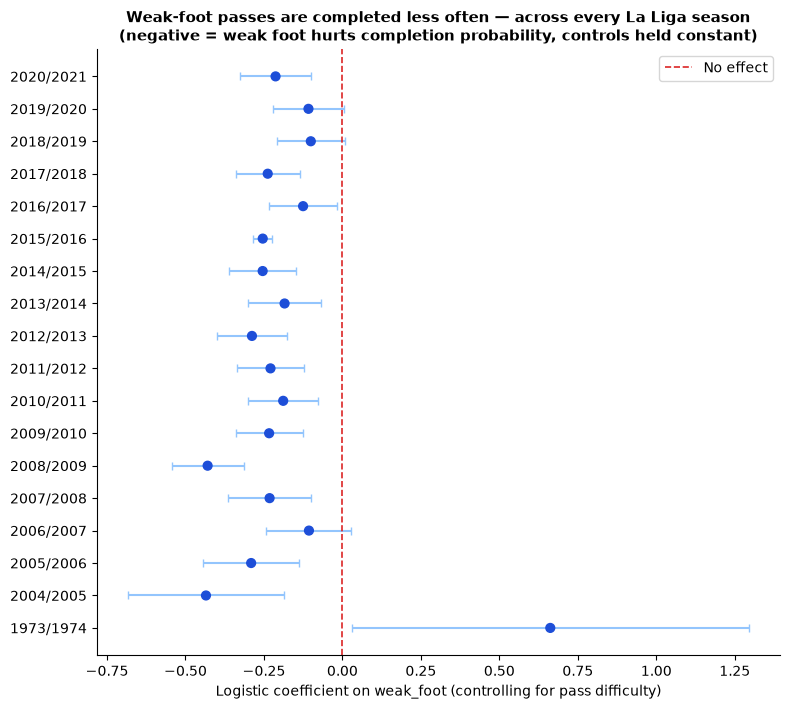

Saved: poster_outputs/weak_foot_hypothesis_by_season.csv
Saved: poster_outputs/weak_foot_forest_plot.png


,season,n_passes,strong_foot_completion,weak_foot_completion,raw_gap_pp,chi2,chi2_pvalue,logit_weak_foot_coef,logit_ci_low,logit_ci_high,logit_pvalue,fit_method,controls_used,controls_dropped,logit_error
0,1973/1974,469,0.696570,0.811111,-11.454119,4.168798,4.117499e-02,0.662202,0.029282,1.295122,4.030185e-02,statsmodels_logit,"pass_length,under_pressure,pass_cross_f,pass_s...",pass_cut_back_f,
1,2004/2005,3871,0.813685,0.783838,2.984645,2.307403,1.287590e-01,-0.434695,-0.683831,-0.185558,6.267851e-04,statsmodels_logit,"pass_length,under_pressure,pass_cross_f,pass_s...",pass_cut_back_f,
2,2005/2006,10181,0.798267,0.782676,1.559138,1.596832,2.063528e-01,-0.290797,-0.442662,-0.138931,1.747331e-04,statsmodels_logit,"pass_length,under_pressure,pass_cross_f,pass_s...",pass_cut_back_f,
3,2006/2007,17564,0.842236,0.859266,-1.702955,4.264850,3.890868e-02,-0.106647,-0.242164,0.028870,1.229707e-01,statsmodels_logit,"pass_length,under_pressure,pass_cross_f,pass_s...",pass_cut_back_f,
4,2007/2008,18682,0.845146,0.846957,-0.181168,0.035896,8.497313e-01,-0.232005,-0.363377,-0.100634,5.374807e-04,statsmodels_logit,"pass_length,under_pressure,pass_cross_f,pass_s...",pass_cut_back_f,
5,2008/2009,20054,0.829205,0.790648,3.855720,20.920494,4.787452e-06,-0.429494,-0.543997,-0.314991,1.956840e-13,statsmodels_logit,"pass_length,under_pressure,pass_cross_f,pass_s...",pass_cut_back_f,
6,2009/2010,24834,0.841469,0.838291,0.317790,0.185263,6.668888e-01,-0.233503,-0.340601,-0.126404,1.926515e-05,statsmodels_logit,"pass_length,under_pressure,pass_cross_f,pass_s...",pass_cut_back_f,
7,2010/2011,26458,0.870306,0.862956,0.734997,1.325048,2.496881e-01,-0.188720,-0.300617,-0.076823,9.478117e-04,statsmodels_logit,"pass_length,under_pressure,pass_cross_f,pass_s...",pass_cut_back_f,
8,2011/2012,28414,0.855210,0.849584,0.562575,0.710555,3.992598e-01,-0.229147,-0.335207,-0.123087,2.289918e-05,statsmodels_logit,"pass_length,under_pressure,pass_cross_f,pass_s...",pass_cut_back_f,
9,2012/2013,26334,0.867330,0.859181,0.814902,1.552868,2.127125e-01,-0.288218,-0.400529,-0.175907,4.910823e-07,statsmodels_logit,"pass_length,under_pressure,pass_cross_f,pass_s...",pass_cut_back_f,


In [12]:
if hypothesis_rows:
    hyp_df = pd.DataFrame(hypothesis_rows)
    hyp_df.to_csv(OUT_DIR / "weak_foot_hypothesis_by_season.csv", index=False)
    plot_weak_foot_forest(hyp_df, OUT_DIR / "weak_foot_forest_plot.png")
    print(f"Saved: {OUT_DIR / 'weak_foot_hypothesis_by_season.csv'}")
    print(f"Saved: {OUT_DIR / 'weak_foot_forest_plot.png'}")
    display(hyp_df)
else:
    print("No seasons produced valid hypothesis-test results.")


## CELL 13 — Save calibration analyses (by pass type + by season)

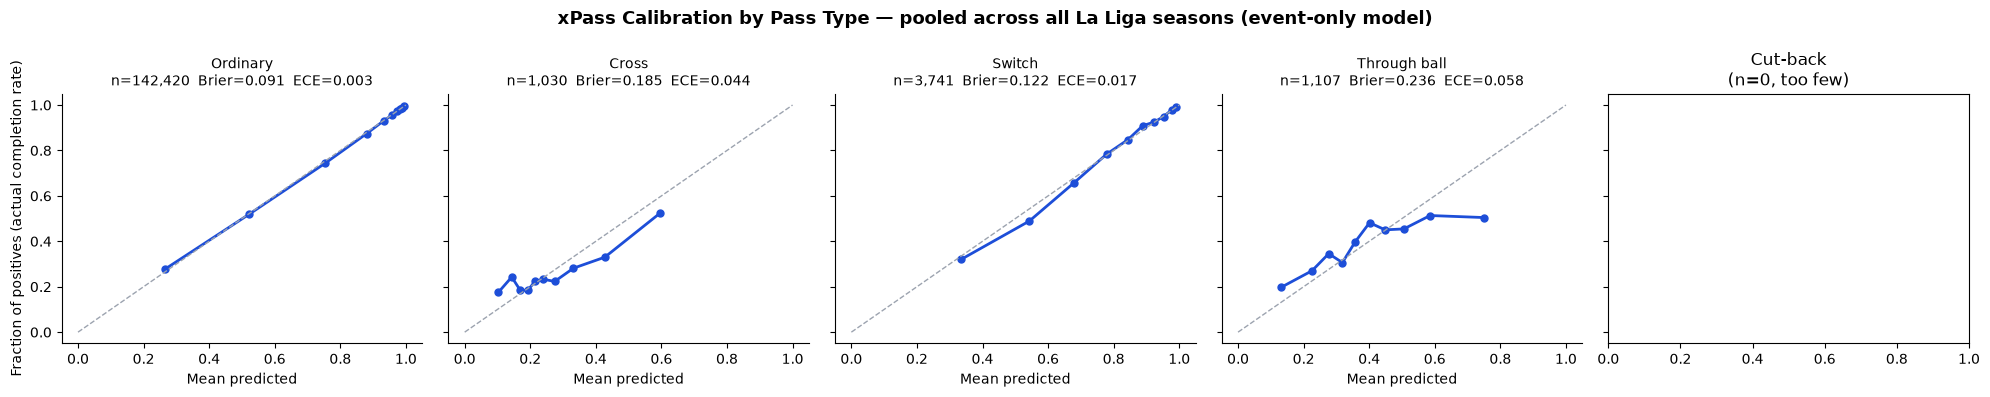

Saved: poster_outputs/calibration_by_pass_type.png
Saved: poster_outputs/calibration_summary_by_pass_type.csv
Saved: poster_outputs/calibration_summary_by_season.csv


,pass_type,n,actual_rate,predicted_rate,gap_pp,brier_score,ece
0,Ordinary,142420,0.823557,0.824307,-0.075018,0.090569,0.003293
1,Cross,1030,0.260194,0.269109,-0.891525,0.184960,0.043548
2,Switch,3741,0.784817,0.790882,-0.606504,0.121749,0.016927
3,Through ball,1107,0.392051,0.400205,-0.815440,0.235614,0.057798


,season,n_test_passes,auc,brier_score,ece
0,2004/2005,1477,0.876353,0.106407,0.029863
1,2005/2006,2945,0.853251,0.132173,0.030728
2,2006/2007,4819,0.893191,0.087836,0.008659
3,2007/2008,4796,0.880099,0.096851,0.021865
4,2008/2009,5280,0.871052,0.108802,0.016336
5,2009/2010,5872,0.881748,0.094627,0.009663
6,2010/2011,6368,0.904076,0.078768,0.012307
7,2011/2012,7529,0.876545,0.086301,0.014235
8,2012/2013,6619,0.897897,0.074239,0.008148
9,2013/2014,6114,0.895790,0.089258,0.010610


In [13]:
if pooled_preds:
    all_preds = pd.concat(pooled_preds, ignore_index=True)

    pass_type_summary = calibration_by_pass_type(
        all_preds,
        OUT_DIR / "calibration_by_pass_type.png",
        OUT_DIR / "calibration_summary_by_pass_type.csv",
    )
    season_summary = calibration_by_season(
        results_by_season, OUT_DIR / "calibration_summary_by_season.csv"
    )

    print(f"Saved: {OUT_DIR / 'calibration_by_pass_type.png'}")
    print(f"Saved: {OUT_DIR / 'calibration_summary_by_pass_type.csv'}")
    print(f"Saved: {OUT_DIR / 'calibration_summary_by_season.csv'}")

    display(pass_type_summary)
    display(season_summary)
else:
    print("No seasons produced held-out predictions for calibration analysis.")


## CELL 14 — Optional bonus: run the 2020/21 event-only vs 360 comparison
Set `RUN_360_BONUS = True` in Cell 1 (or just call the function below directly) to run this.

In [14]:
if RUN_360_BONUS:
    run_2020_21_event_vs_360_bonus()
else:
    print("RUN_360_BONUS is False — set it to True in Cell 1 to run the 2020/21 "
          "event-only vs 360 bonus comparison.")


RUN_360_BONUS is False — set it to True in Cell 1 to run the 2020/21 event-only vs 360 bonus comparison.


## Poster assets summary

All figures and CSVs are written to `./poster_outputs/`:

| File | Contents |
|---|---|
| `weak_foot_hypothesis_by_season.csv` | per-season completion gap, chi-square, controlled logistic coefficient/CI/p-value |
| `weak_foot_forest_plot.png` | forest plot of the controlled weak-foot effect across all seasons |
| `calibration_by_pass_type.png` | reliability diagrams, one panel per pass type, pooled across seasons |
| `calibration_summary_by_pass_type.csv` | Brier score / ECE / n per pass type, pooled across seasons |
| `calibration_summary_by_season.csv` | AUC / Brier / ECE per season (event-only model) |
| `event_vs_360_2020_21.png` *(optional)* | 2020/21 event-only vs 360-enriched calibration comparison |
